In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import os
print(os.listdir('.'))

['amazon_sentiment-analysis.ipynb', 'test.ft.txt.bz2', 'train.ft.txt.bz2']


In [5]:
import bz2

# Read compressed file
with bz2.open('train.ft.txt.bz2', 'rt', encoding='utf-8') as f:
    lines = [next(f) for _ in range(50000)]

# Parse into dataframe
labels = []
reviews = []
for line in lines:
    label = line.split(' ')[0]
    review = ' '.join(line.split(' ')[1:])
    labels.append(label)
    reviews.append(review)

df = pd.DataFrame({'label': labels, 'review': reviews})
print("Shape:", df.shape)
print(df.head())

Shape: (50000, 2)
        label                                             review
0  __label__2  Stuning even for the non-gamer: This sound tra...
1  __label__2  The best soundtrack ever to anything.: I'm rea...
2  __label__2  Amazing!: This soundtrack is my favorite music...
3  __label__2  Excellent Soundtrack: I truly like this soundt...
4  __label__2  Remember, Pull Your Jaw Off The Floor After He...


Label Distribution:
label
Positive    25506
Negative    24494
Name: count, dtype: int64


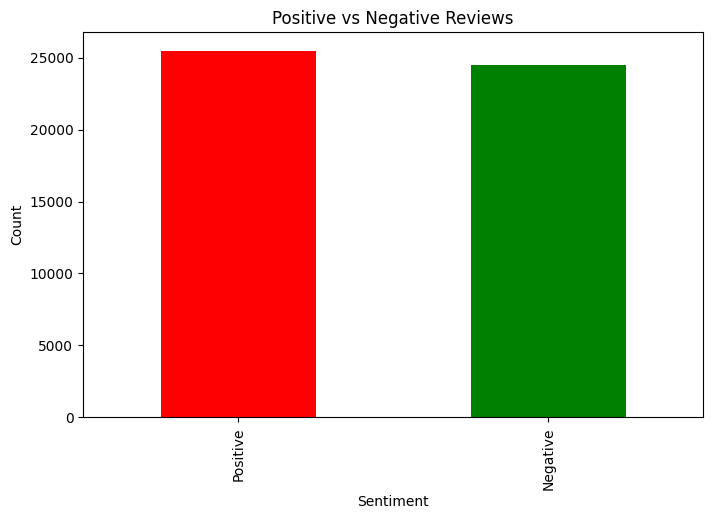

In [6]:
# Clean labels
df['label'] = df['label'].map({'__label__1': 'Negative', '__label__2': 'Positive'})

# Check distribution
print("Label Distribution:")
print(df['label'].value_counts())

# Visualize
plt.figure(figsize=(8,5))
df['label'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Positive vs Negative Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [7]:
# Clean text
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.strip()
    return text

df['clean_review'] = df['review'].apply(clean_text)

print("Sample cleaned reviews:")
print(df['clean_review'].head())

Sample cleaned reviews:
0    stuning even for the nongamer this sound track...
1    the best soundtrack ever to anything im readin...
2    amazing this soundtrack is my favorite music o...
3    excellent soundtrack i truly like this soundtr...
4    remember pull your jaw off the floor after hea...
Name: clean_review, dtype: str


In [8]:
# Build ML Model
X = df['clean_review']
y = df['label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert text to numbers
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train model
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

# Test model
predictions = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy: 0.88

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.86      0.88      4955
    Positive       0.87      0.89      0.88      5045

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



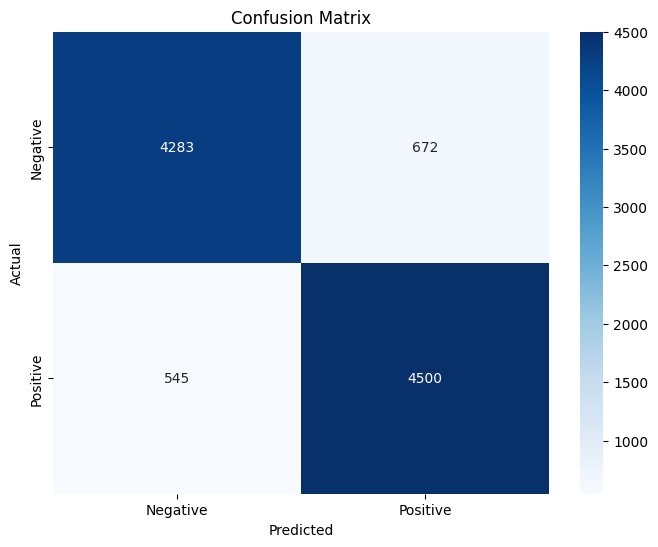


Custom Review Predictions:
Review: This product is amazing! I love it!
Sentiment: Positive

Review: Terrible product, waste of money!
Sentiment: Negative

Review: It was okay, nothing special
Sentiment: Negative



In [9]:
# Visualize results
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Test with custom review
sample_reviews = [
    "This product is amazing! I love it!",
    "Terrible product, waste of money!",
    "It was okay, nothing special"
]

sample_tfidf = tfidf.transform(sample_reviews)
sample_predictions = model.predict(sample_tfidf)

print("\nCustom Review Predictions:")
for review, pred in zip(sample_reviews, sample_predictions):
    print(f"Review: {review}")
    print(f"Sentiment: {pred}\n")